[Intro] This project involves analyzing historical trends of GDP growth in the United States from 2010 to 2023. The data is obtained from the U.S. Bureau of Economic Analysis, where the seasonally adjusted annual rate of real GDP growth is displayed by the quarter. The three methods that will be used to provide predictive plots are cubic spline interpolation, polynomial modeling, and linear least squares model.

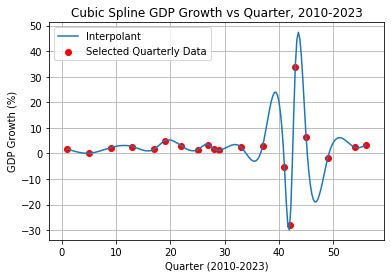

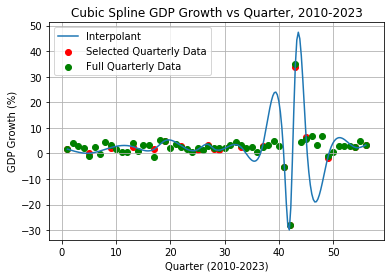

In [18]:
#PART A-----------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def evaluate_spline(x, y, M, h, xeval):
    for i in range(len(x) - 1):
        if x[i] <= xeval <= x[i + 1]:
            term1 = M[i] * (x[i + 1] - xeval)**3 / (6 * h[i])
            term2 = M[i + 1] * (xeval - x[i])**3 / (6 * h[i])
            term3 = (y[i] / h[i] - M[i] * h[i] / 6) * (x[i + 1] - xeval)
            term4 = (y[i + 1] / h[i] - M[i + 1] * h[i] / 6) * (xeval - x[i])
            return term1 + term2 + term3 + term4

def thomas(A, B, C, D):
    n = len(D)
    for i in range(1, n):
        w = A[i] / B[i - 1]
        B[i] = B[i] - w * C[i - 1]
        D[i] = D[i] - w * D[i - 1]

    M = np.zeros(n)
    M[n - 1] = D[n - 1] / B[n - 1]

    for i in range(n - 2, -1, -1):
        M[i] = (D[i] - C[i] * M[i + 1]) / B[i]

    return M

x = np.array([1,5,9,13,17,19,22,25,
             27,28,29,33,37,41,42,43,45,49,54,56])
y = np.array([1.7,0.1,2.3,2.7,1.7,5.0,
             3.0,1.5,3.5,1.8,1.3,2.5,3.1,-5.1,-28.1,
             33.8,6.3,-1.6,2.4,3.3])
x_full = np.arange(1,57,1)
y_full = np.array([1.9,3.9,3.1,2.1,-0.9,2.7,-0.1,4.6,
                  3.4,1.8,0.6,0.5,4.0,1.1,3.5,3.5,
                  -1.4,5.3,5.0,2.0,3.6,2.5,1.6,0.7,
                  2.3,1.3,2.9,2.2,2.0,2.3,3.2,4.6,
                  3.3,2.1,2.5,0.6,2.5,3.4,4.8,2.8,
                  -5.2,-28.0,34.9,4.6,5.7,7.0,3.3,7.0,
                  -1.0,0.6,2.9,2.8,2.9,2.5,4.7,3.4])
n = len(x)
h = np.zeros(n - 1)
for i in range(n - 1):
    h[i] = x[i + 1] - x[i]

A = np.zeros(n)
B = np.zeros(n)
C = np.zeros(n)
D = np.zeros(n)

B[0] = 1
B[n - 1] = 1
D[0] = 0
D[n - 1] = 0

for i in range(1, n - 1):
    A[i] = h[i - 1]
    B[i] = 2 * (h[i - 1] + h[i])
    C[i] = h[i]
    D[i] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

M = thomas(A, B, C, D)

xvals = np.linspace(x[0], x[-1], 200)
yvals = []

for val in xvals:
    yvals.append(evaluate_spline(x, y, M, h, val))

plt.plot(xvals, yvals, label = 'Interpolant')
plt.scatter(x, y, color = 'red', label = 'Selected Quarterly Data')
plt.title('Cubic Spline GDP Growth vs Quarter, 2010-2023')
plt.xlabel('Quarter (2010-2023)')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.grid()
plt.show()

plt.plot(xvals, yvals, label = 'Interpolant')
plt.scatter(x, y, color = 'red', label = 'Selected Quarterly Data')
plt.scatter(x_full, y_full, color = 'green', label = 'Full Quarterly Data')
plt.title('Cubic Spline GDP Growth vs Quarter, 2010-2023')
plt.xlabel('Quarter (2010-2023)')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.grid()
plt.show()

[Part A] This code utilizes the cubic spline interpolation to analyze the selected GDP quarterly data. The first graph utilizes the selected data points to create the interpolation, while the second graph compares the estimate with the full range of data at every quarter. In order accomplish this, 55 unknown intervals (55 spline intervals from 56 data points) with 4 unknown polynomial coefficients each (220 total unknowns) must be evaluated. Since the first and last points are endpoints, there are only 54 interior knots. Each of these knots must satisfy 3 continuity conditions: function, first, and second derivative continuity (the function and its first and second derivatives must be continuous). For a natural spline, the second derivative at both endpoints must be equal to zero. The resulting tridiagonal system was solved using the Thomas algorithm, which is an efficient method for solving systems of this form.

When interpolating over the selected data, the spline passed through all points provided, and the interpolant was smooth and reasonable for the majority of the data. However, the graph began to greatly oscillate around quarter 35 and provided overestimates, or "peaks", in the data. This is especially apparent when the spline was compared against the full dataset. The oscillations greatly overshot multiple datapoints and thus provided unreasonable estimates in that area.

The outliers presented in the data are a result of the COVID pandemic's negative effect on the GDP and subsequent recovery. The spline had to pass through all data points including the outliers; this is similar to Runge phenomenon behavior, where exact interpolation of extreme points can produce instability and overshooting. This is an arguable downside to exact interpolation; numerical stability is sacrificed to account for the outliers. In order to provide more accurate predictions for the data trends, a weighted least squares would provide better representation for the data overall.

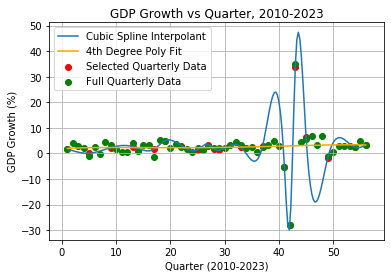

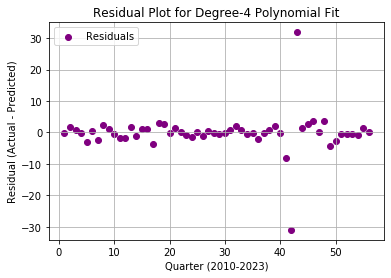

In [28]:
#Part B1---------------------------------------------------------------------
def polynomial_least_squares(X, Y, degree):
    A = np.column_stack([X**i for i in range(degree, -1, -1)])
    ATA = A.T @ A
    ATY = A.T @ Y
    coeffs = np.linalg.solve(ATA, ATY)
    return coeffs

def evaluate_polynomial(coeffs, X):
    Y = np.zeros(len(X))
    degree = len(coeffs) - 1
    for i in range(len(coeffs)):
        Y += coeffs[i] * X**(degree - i)
    return Y

X_raw = np.arange(1,57)
X = (X_raw - 1) / 55
Y = np.array([1.9,3.9,3.1,2.1,-0.9,2.7,-0.1,4.6,
                  3.4,1.8,0.6,0.5,4.0,1.1,3.5,3.5,
                  -1.4,5.3,5.0,2.0,3.6,2.5,1.6,0.7,
                  2.3,1.3,2.9,2.2,2.0,2.3,3.2,4.6,
                  3.3,2.1,2.5,0.6,2.5,3.4,4.8,2.8,
                  -5.2,-28.0,34.9,4.6,5.7,7.0,3.3,7.0,
                  -1.0,0.6,2.9,2.8,2.9,2.5,4.7,3.4])

coeffs = polynomial_least_squares(X, Y, 4)

X_plot = np.linspace(0,1,200)
Y_plot = evaluate_polynomial(coeffs, X_plot)

plt.figure()
plt.plot(xvals, yvals, label = 'Cubic Spline Interpolant')
plt.scatter(x, y, color = 'red', label = 'Selected Quarterly Data')
plt.scatter(x_full, y_full, color = 'green', label = 'Full Quarterly Data')
plt.plot(X_plot*55+1, Y_plot, color='orange', label='4th Degree Poly Fit')
plt.title('GDP Growth vs Quarter, 2010-2023')
plt.xlabel('Quarter (2010-2023)')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.grid()
plt.show()

Y_pred = evaluate_polynomial(coeffs, X)
residuals = Y - Y_pred

plt.figure()
plt.scatter(X_raw, residuals, color='purple', label='Residuals')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot for Degree-4 Polynomial Fit')
plt.xlabel('Quarter (2010-2023)')
plt.ylabel('Residual (Actual - Predicted)')
plt.legend()
plt.grid()
plt.show()

[Part B1] This code implemented a 4th degree polynomial utilizing the least squares method, and the resulting graph was compared against the cubic spline interpolation. The least squares model did not chase the outliers as the spline did; it produced an almost linear model that better encapsulated the overall trend in data over time. Although this can be effective in modeling general trends in data, the spline interpolation is more effective in capturing specific data points since it accounts for the COVID data. This is also seen in the residual graph of the polynomial model. There is little error in the data until the COVID outliers are present.

Slope = 0.02357087732071345
Intercept = 1.9872278121587204


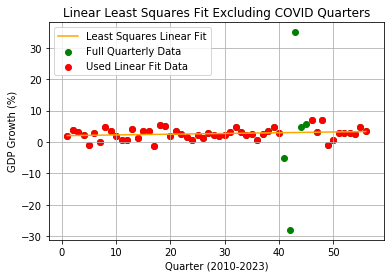

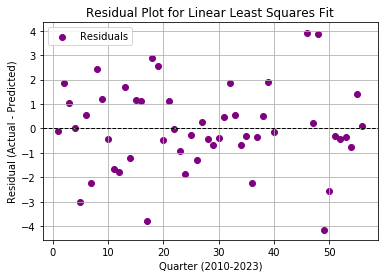

In [30]:
#Part B2-----------------------------------------
def least_squares(X, Y):
    A = np.column_stack([X, np.ones(len(X))])
    ATA = A.T @ A
    ATY = A.T @ Y
    m, b = np.linalg.solve(ATA, ATY)
    return m, b

X_full = np.arange(1, 57)
Y_full = np.array([1.9,3.9,3.1,2.1,-0.9,2.7,-0.1,4.6,
                   3.4,1.8,0.6,0.5,4.0,1.1,3.5,3.5,
                   -1.4,5.3,5.0,2.0,3.6,2.5,1.6,0.7,
                   2.3,1.3,2.9,2.2,2.0,2.3,3.2,4.6,
                   3.3,2.1,2.5,0.6,2.5,3.4,4.8,2.8,
                   -5.2,-28.0,34.9,4.6,5.7,7.0,3.3,7.0,
                   -1.0,0.6,2.9,2.8,2.9,2.5,4.7,3.4])

remove = [40, 41, 42, 43, 44]

X = np.delete(X_full, remove)
Y = np.delete(Y_full, remove)

m, b = least_squares(X, Y)

Y_pred = m * X + b
residuals = Y - Y_pred

X_plot = np.linspace(1, 56, 200)
Y_plot = m * X_plot + b

print("Slope =", m)
print("Intercept =", b)

plt.figure()
plt.scatter(X_full, Y_full, color='green', label='Full Quarterly Data')
plt.scatter(X, Y, color='red', label='Used Linear Fit Data')
plt.plot(X_plot, Y_plot, color='orange', label='Least Squares Linear Fit')
plt.title('Linear Least Squares Fit Excluding COVID Quarters')
plt.xlabel('Quarter (2010-2023)')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.scatter(X, residuals, color='purple', label='Residuals')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot for Linear Least Squares Fit')
plt.xlabel('Quarter (2010-2023)')
plt.ylabel('Residual (Actual - Predicted)')
plt.legend()
plt.grid()
plt.show()



[Part B2] The code excludes the COVID outlier data and provides a linear least squares model to the remaining data. The slope of the model is approximately 0.02357; this suggests that there is a slight overall rise in GDP growth over time. Since the majority of data points fit this trend (and consistent reported residuals), this linear model is appropriate for modeling the overall trend in data. However, this does come with a critical assumption. The linear model excludes the outlier data points and suggests that such spikes in the data are not commonplace.

[Part C] A policymaker who needs to estimate GDP growth between two known data points should utilize cubic spline interpolation. This is because the cubic spline model produces a smooth curve through two locally known data points, thus providing an accurate estimate within the interval. The spline's sensitivity to data variation enables the policymaker to analyze trends over a small time period as opposed to global trends. However, it is important to note that the oscillatory behavior can skew estimates near any apparent outliers.

Big O notation involves analyzing the runtimes of various code depending on their complexity. All three methods are of the form O(n); this means that the runtimes of all methods increase linearly with the number of data points. Because of this, the variation of complexity between computations is not significant enough to warrant influence on which modeling choice to use. The method should be chosen based on the behavior and accuracy of each model.

[Conclusion] Each method of modeling comes with its own strengths and weaknesses, and different analyses warrant the use of different models. For interpolation, the cubic spline model is the most effective. This is due to its sensitivity to local data variation (including outliers) as well as its ability to produce smooth curves within each interval. However, it is this sensitivity to outliers that makes it less effective at modeling general trends in data. Such global trend analysis requires the use of the polynomial fitting and linear least squares modeling. These methods provide estimates based on the overall trends in data, and they do not "chase" outliers as the cubic spline does. It is important to note that for the linear model specifically, it is only effective when the data points produce an overall linear trend; otherwise, the polynomial fitting should be used.